<a href="https://colab.research.google.com/github/juzt-me/Customer-Transaction/blob/main/DShackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

In [8]:
import os

print(os.listdir())

['.config', 'bank_transactions.csv', 'sample_data']


In [9]:
df = pd.read_csv("bank_transactions.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1048567
Columns: 9


In [11]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [13]:
missing = df.isnull().sum()

print(missing)

TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64


In [14]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

TransactionID              0.000000
CustomerID                 0.000000
CustomerDOB                0.323966
CustGender                 0.104905
CustLocation               0.014401
CustAccountBalance         0.225927
TransactionDate            0.000000
TransactionTime            0.000000
TransactionAmount (INR)    0.000000
dtype: float64


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1048567


In [17]:
print("Duplicate Transaction IDs:",
      df['TransactionID'].duplicated().sum())

Duplicate Transaction IDs: 0


In [19]:
df['CustomerDOB'] = pd.to_datetime(
    df['CustomerDOB'],
    errors='coerce',
    dayfirst=True
)
df['CustomerDOB'].head()

/tmp/ipykernel_3096/270362007.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CustomerDOB'] = pd.to_datetime(


,CustomerDOB
0,1994-01-10
1,2057-04-04
2,1996-11-26
3,2073-09-14
4,1988-03-24


In [20]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    errors='coerce',
    dayfirst=True
)

/tmp/ipykernel_3096/1286031432.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate'] = pd.to_datetime(


In [21]:
df['TransactionDate'].head()

,TransactionDate
0,2016-08-02
1,2016-08-02
2,2016-08-02
3,2016-08-02
4,2016-08-02


In [22]:
df['CustAccountBalance'] = pd.to_numeric(
    df['CustAccountBalance'],
    errors='coerce'
)

df['TransactionAmount (INR)'] = pd.to_numeric(
    df['TransactionAmount (INR)'],
    errors='coerce'
)

In [23]:
df['CustAccountBalance'] = df['CustAccountBalance'].fillna(
    df['CustAccountBalance'].median()
)

In [24]:
df['CustGender'] = df['CustGender'].fillna('Unknown')

In [25]:
df['CustLocation'] = df['CustLocation'].fillna('Unknown')

In [26]:
df['CustomerDOB'] = df['CustomerDOB'].fillna(
    df['CustomerDOB'].mode()[0]
)

In [27]:
df['Age'] = (
    df['TransactionDate'].dt.year -
    df['CustomerDOB'].dt.year
)

In [28]:
df['Age'].describe()

,Age
count,1.048567e+06
mean,3.053495e+01
std,5.253733e+01
min,-5.900000e+01
25%,2.400000e+01
50%,2.700000e+01
75%,3.200000e+01
max,2.160000e+02


In [29]:
df = df[
    (df['Age'] >= 18) &
    (df['Age'] <= 100)
]

In [30]:
def age_group(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    elif age <= 55:
        return '46-55'
    else:
        return '56+'

df['Age_Group'] = df['Age'].apply(age_group)

In [31]:
df['Age_Group'].value_counts()

,count
Age_Group,
26-35,499851
18-25,269948
36-45,98815


In [32]:
df['Transaction_Year'] = df['TransactionDate'].dt.year

df['Transaction_Month'] = df['TransactionDate'].dt.month

df['Transaction_Month_Name'] = (
    df['TransactionDate'].dt.month_name()
)

In [33]:
customer_df = df.groupby('CustomerID').agg(

    Total_Transactions=('TransactionID', 'count'),

    Total_Transaction_Amount=(
        'TransactionAmount (INR)',
        'sum'
    ),

    Average_Transaction_Amount=(
        'TransactionAmount (INR)',
        'mean'
    ),

    Maximum_Transaction_Amount=(
        'TransactionAmount (INR)',
        'max'
    ),

    Average_Account_Balance=(
        'CustAccountBalance',
        'mean'
    ),

    Age=('Age', 'first'),

    Age_Group=('Age_Group', 'first'),

    Gender=('CustGender', 'first'),

    City=('CustLocation', 'first')

).reset_index()

In [34]:
customer_df.head()

,CustomerID,Total_Transactions,Total_Transaction_Amount,Average_Transaction_Amount,Maximum_Transaction_Amount,Average_Account_Balance,Age,Age_Group,Gender,City
0,C1010011,2,5106.0,2553.0,4750.0,76340.635,24,18-25,F,NOIDA
1,C1010012,1,1499.0,1499.0,1499.0,24204.490,22,18-25,M,MUMBAI
2,C1010014,2,1455.0,727.5,1205.0,100112.950,24,18-25,F,MUMBAI
3,C1010018,1,30.0,30.0,30.0,496.180,26,26-35,F,CHAMPARAN
4,C1010028,1,557.0,557.0,557.0,296828.370,28,26-35,F,DELHI


In [35]:
print("Customer-level rows:", customer_df.shape[0])
print("Customer-level columns:", customer_df.shape[1])

Customer-level rows: 753091
Customer-level columns: 10


In [36]:
customer_df.describe()

,Total_Transactions,Total_Transaction_Amount,Average_Transaction_Amount,Maximum_Transaction_Amount,Average_Account_Balance,Age
count,753091.000000,7.530910e+05,7.530910e+05,7.530910e+05,7.530910e+05,753091.000000
mean,1.153398,1.453447e+03,1.260554e+03,1.399482e+03,7.517730e+04,28.561713
std,0.406277,5.828619e+03,5.357440e+03,5.787619e+03,3.265550e+05,4.955075
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,18.000000
25%,1.000000,1.730000e+02,1.561250e+02,1.680000e+02,4.822050e+03,25.000000
50%,1.000000,4.800000e+02,4.136800e+02,4.516600e+02,1.569662e+04,28.000000
75%,1.000000,1.222460e+03,1.028000e+03,1.149000e+03,4.780498e+04,32.000000
max,6.000000,1.560035e+06,1.560035e+06,1.560035e+06,2.797959e+07,40.000000


In [37]:
customer_df['Gender'].value_counts()

,count
Gender,
M,543660
F,209431


In [38]:
customer_df['Age_Group'].value_counts()

,count
Age_Group,
26-35,433589
18-25,233857
36-45,85645


In [39]:
customer_df['City'].value_counts().head(10)

,count
City,
MUMBAI,73609
BANGALORE,60205
NEW DELHI,56593
GURGAON,53963
DELHI,52045
NOIDA,24525
CHENNAI,19892
PUNE,18681
HYDERABAD,17009


In [41]:
customer_df.sort_values(
    'Total_Transaction_Amount',
    ascending=False
).head(10)

,CustomerID,Total_Transactions,Total_Transaction_Amount,Average_Transaction_Amount,Maximum_Transaction_Amount,Average_Account_Balance,Age,Age_Group,Gender,City
587661,C7319271,1,1560034.99,1560034.990,1560034.99,42487.890,40,36-45,M,GURGAON
528882,C6677159,1,1380002.88,1380002.880,1380002.88,98660.330,38,36-45,F,PUNE
295492,C4141768,1,991132.22,991132.220,991132.22,83608.100,40,36-45,M,NEW DELHI
79221,C1830891,1,720001.16,720001.160,720001.16,14177.650,31,26-35,F,KOLKATA
518783,C6549785,1,600008.32,600008.320,600008.32,29198.460,28,26-35,F,NOIDA
377822,C5036642,1,600003.45,600003.450,600003.45,136294.600,27,26-35,M,NEW DELHI
40657,C1425138,1,561001.00,561001.000,561001.00,9324.350,33,26-35,M,MUMBAI
236714,C3528755,4,550972.34,137743.085,550004.34,14068.165,28,26-35,M,LUCKNOW
10626,C1115779,1,525003.83,525003.830,525003.83,38329.460,35,26-35,M,NEW DELHI
461814,C5938826,1,520009.87,520009.870,520009.87,13357.200,28,26-35,M,NOIDA


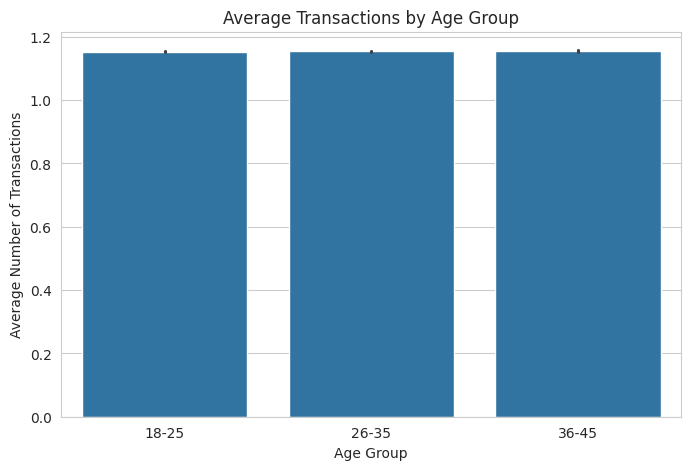

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_df,
    x='Age_Group',
    y='Total_Transactions',
    estimator='mean'
)

plt.title('Average Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Number of Transactions')

plt.show()

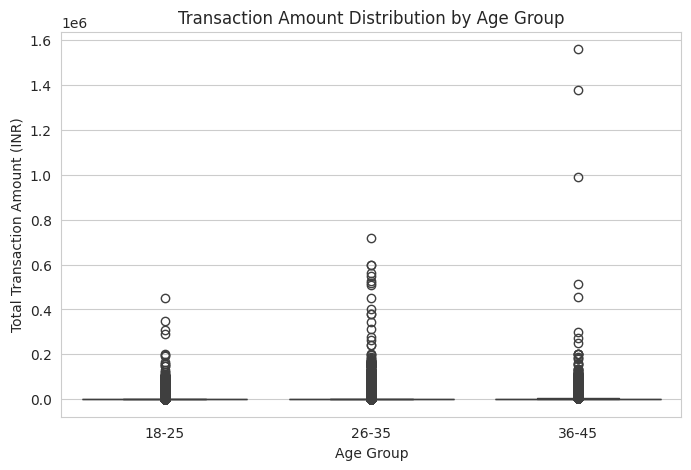

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_df,
    x='Age_Group',
    y='Total_Transaction_Amount'
)

plt.title('Transaction Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Transaction Amount (INR)')

plt.show()

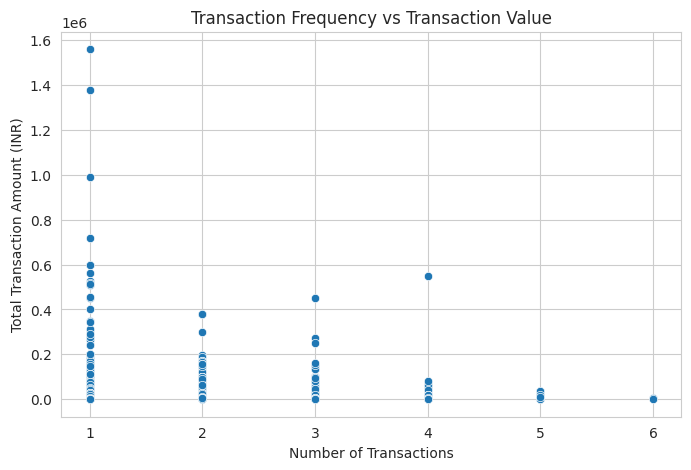

In [44]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customer_df,
    x='Total_Transactions',
    y='Total_Transaction_Amount'
)

plt.title('Transaction Frequency vs Transaction Value')
plt.xlabel('Number of Transactions')
plt.ylabel('Total Transaction Amount (INR)')

plt.show()

In [45]:
monthly_data = df.groupby(
    'Transaction_Month_Name'
)['TransactionAmount (INR)'].sum()

In [46]:
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_data = monthly_data.reindex(
    [m for m in month_order if m in monthly_data.index]
)

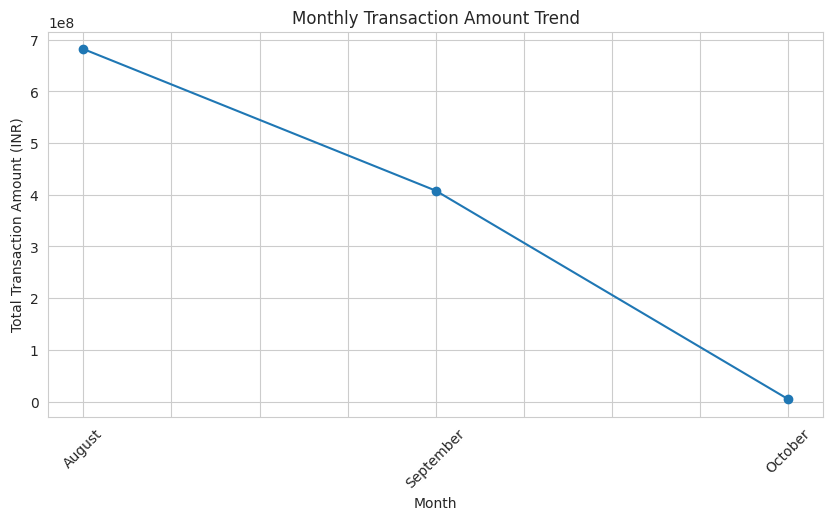

In [47]:
plt.figure(figsize=(10,5))

monthly_data.plot(marker='o')

plt.title('Monthly Transaction Amount Trend')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount (INR)')

plt.xticks(rotation=45)

plt.show()

In [48]:
transaction_threshold = customer_df[
    'Total_Transactions'
].quantile(0.75)

customer_df['High_Frequency'] = (
    customer_df['Total_Transactions']
    >= transaction_threshold
).astype(int)

In [49]:
value_threshold = customer_df[
    'Total_Transaction_Amount'
].quantile(0.75)

customer_df['High_Value_Customer'] = (
    customer_df['Total_Transaction_Amount']
    >= value_threshold
).astype(int)

In [50]:
features = [
    'Total_Transactions',
    'Average_Transaction_Amount',
    'Average_Account_Balance',
    'Age'
]

X = customer_df[features]

y = customer_df['High_Value_Customer']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [53]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [54]:
y_pred = knn.predict(X_test_scaled)

In [55]:
accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.99575750735299


In [56]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    112964
           1       0.99      0.99      0.99     37655

    accuracy                           1.00    150619
   macro avg       0.99      0.99      0.99    150619
weighted avg       1.00      1.00      1.00    150619



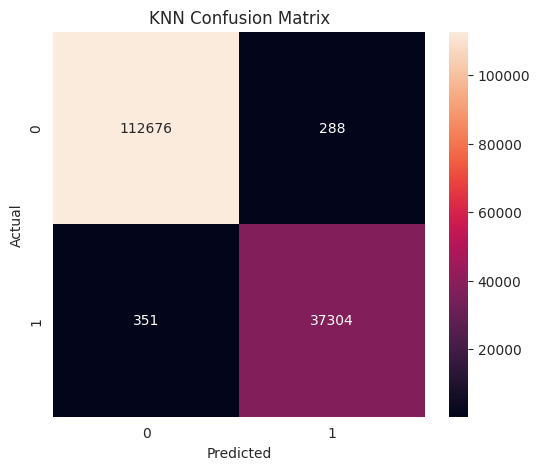

In [57]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [58]:
k_values = range(1, 16)

accuracy_values = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    accuracy_values.append(
        accuracy_score(
            y_test,
            prediction
        )
    )

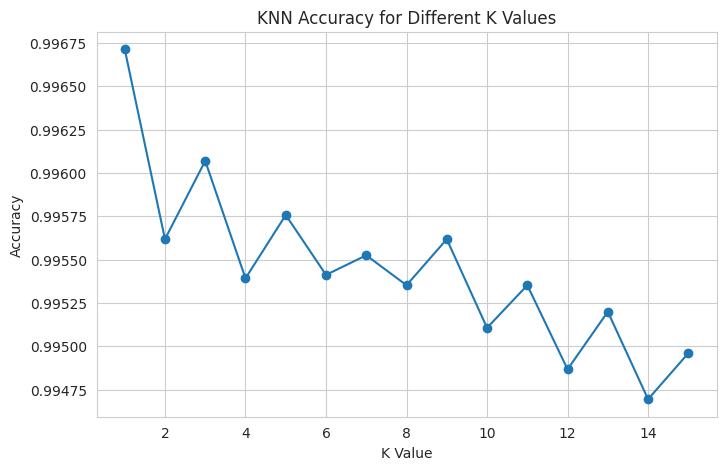

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracy_values,
    marker='o'
)

plt.xlabel('K Value')
plt.ylabel('Accuracy')

plt.title('KNN Accuracy for Different K Values')

plt.show()

In [60]:
best_k = k_values[
    np.argmax(accuracy_values)
]

best_accuracy = max(accuracy_values)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 1
Best Accuracy: 0.9967135620340063


In [61]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check duplicate transaction IDs
print(
    "Duplicate Transaction IDs:",
    df['TransactionID'].duplicated().sum()
)

Missing values:
TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
Age                        0
Age_Group                  0
Transaction_Year           0
Transaction_Month          0
Transaction_Month_Name     0
dtype: int64

Duplicate rows: 0
Duplicate Transaction IDs: 0


In [62]:
# Check negative transaction amounts
print("Negative Transaction Amounts:",
      (df['TransactionAmount (INR)'] < 0).sum())

# Check negative account balances
print("Negative Account Balances:",
      (df['CustAccountBalance'] < 0).sum())

Negative Transaction Amounts: 0
Negative Account Balances: 0


In [63]:
print("Transaction Amount Statistics:")
print(df['TransactionAmount (INR)'].describe())

print("\nAccount Balance Statistics:")
print(df['CustAccountBalance'].describe())

Transaction Amount Statistics:
count    8.686140e+05
mean     1.260143e+03
std      5.405778e+03
min      0.000000e+00
25%      1.439100e+02
50%      3.900000e+02
75%      1.000000e+03
max      1.560035e+06
Name: TransactionAmount (INR), dtype: float64

Account Balance Statistics:
count    8.686140e+05
mean     7.529724e+04
std      3.432656e+05
min      0.000000e+00
25%      4.184280e+03
50%      1.443820e+04
75%      4.560816e+04
max      4.316556e+07
Name: CustAccountBalance, dtype: float64


In [64]:
print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())

Minimum Age: 18
Maximum Age: 40


In [65]:
print("Customers below 18:",
      (df['Age'] < 18).sum())

print("Customers above 100:",
      (df['Age'] > 100).sum())

Customers below 18: 0
Customers above 100: 0


In [66]:
print(df['CustGender'].value_counts())

CustGender
M    627175
F    241439
Name: count, dtype: int64


In [67]:
print("Number of unique locations:",
      df['CustLocation'].nunique())

print("\nTop 10 locations:")
print(df['CustLocation'].value_counts().head(10))

Number of unique locations: 7413

Top 10 locations:
CustLocation
MUMBAI       84819
BANGALORE    69399
NEW DELHI    65399
GURGAON      62007
DELHI        60076
NOIDA        28336
CHENNAI      22901
PUNE         21720
HYDERABAD    19534
THANE        18568
Name: count, dtype: int64
